# Hito 2 — Detección de Ataques de Presentación en Documentos de Identidad

**Trabajo de Fin de Máster** · Protocolo IJCB 2025 PAD-ID Card Challenge (ISO/IEC 30107-3)

El objetivo de este hito es construir un sistema de experimentación que permita comparar
distintas arquitecturas y configuraciones de forma rigurosa. Para ello se usa un único
archivo con una configuración base y una lista de experimentos donde cada entrada solo
define lo que cambia respecto al caso general. Añadir una prueba nueva es cuestión de
escribir un bloque de pocas líneas.

El sistema aguanta desconexiones de Colab sin perder trabajo: guarda el estado completo
tras cada época y reanuda automáticamente al volver a ejecutar.

Árbol de carpetas en Drive:

    TFM_ID_Cards/
      segmentado/               Hito 1, solo lectura
      pickles/df_cross.pkl     generado una vez
      hito2/
        exp01_baseline/        checkpoints · resultados · figuras
        exp02_dropout_07/
        exp03_nopad/
        exp04_pad_15/
        exp05_vit_lora/
        exp06_dinov2_unfreeze/
        global_summary.csv

## Dependencias

In [ ]:
!pip install -q \
    albumentations>=1.3.0 \
    timm>=0.9.0 \
    open-clip-torch \
    transformers==4.40.0 \
    peft==0.10.0 \
    scipy scikit-learn
!pip install -q timm --upgrade

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


## Configuración y experimentos

El sistema se controla con dos estructuras. La primera, BASE_CONFIG, recoge todos los
hiperparámetros compartidos: tamaño de imagen, batch, épocas, learning rates por
arquitectura, etc. La segunda, EXPERIMENTS_TO_RUN, es la lista de pruebas a ejecutar,
donde cada entrada solo necesita especificar lo que difiere del caso base.

El merge de configuraciones es inteligente: si un experimento sobreescribe un
diccionario anidado como model_lr, combina las claves en lugar de reemplazar el
diccionario entero. Así se puede cambiar el learning rate de un único modelo sin
redefinir toda la tabla.

Cada experimento lleva un campo de hipótesis que documenta el razonamiento detrás
de esa configuración. Resulta muy útil cuando se analizan resultados días después.

In [ ]:
BASE_CONFIG: dict = {
    # Rutas
    'drive_root':     'TFM_ID_Cards',
    'local_data_dir': '/content/data_tfm',

    # Reproducibilidad
    'data_seed': 42,

    # Imágenes y carga de datos
    'img_size':        224,
    'batch_train':      64,
    'batch_val':       128,
    'num_workers':       2,
    'syn_train_ratio':  0.30,

    # Clasificación multiclase
    'num_classes': 4,
    'class_names': ['bonafide', 'print', 'screen', 'composite'],
    'label_map': {
        'bonafide':  0,
        'print':     1,
        'printed':   1,
        'screen':    2,
        'composite': 3,
    },

    # Cabeza clasificadora compartida por todos los modelos:
    # Linear(head_hidden) - BN -> Dropout(head_dropout) - ReLU - Linear(num_classes)
    'head_hidden': 256,

    # Entrenamiento
    'max_epochs':    150,
    'patience':       20,
    'weight_decay':  1e-2,
    'grad_clip':      1.0,
    'scheduler_type': 'cosine',   # 'cosine' o 'plateau'

    # Learning rates
    'model_lr': {
        'efficientnet_b4':   1e-4,
        'mobilenetv3_large': 1e-4,
        'dinov2':            5e-4,
        'clip':              3e-4,
        'vit_lora':          3e-4,
    },

    # LoRA (experimento 5, diferido al Hito 3)
    'lora_r':       8,
    'lora_alpha':  16,
    'lora_dropout': 0.1,
}


EXPERIMENTS_TO_RUN: list[dict] = [
    {
        'exp_id':           'exp01_baseline',
        'note':             ('Referencia principal. Los cuatro modelos con '
                             'configuracion estandar: dropout 0.5 y padding '
                             'del 8%. Punto de comparacion para el resto.'),
        'models_to_train':  ['efficientnet_b4', 'mobilenetv3_large', 'dinov2', 'clip'],
        'head_dropout':     0.5,
        'context_pad_frac': 0.08,
        'run_seeds':        [0, 1, 2],
    },
    {
        'exp_id':           'exp02_dropout_07',
        'note':             ('Hipotesis: un dropout mas agresivo (0.7) reduce '
                             'el sobreajuste con un dataset de tamano moderado '
                             'y mejora la generalizacion al cambio de dominio '
                             'ID Cards a SYN PASS.'),
        'models_to_train':  ['efficientnet_b4', 'mobilenetv3_large', 'dinov2', 'clip'],
        'head_dropout':     0.7,
        'context_pad_frac': 0.08,
        'run_seeds':        [0, 1, 2],
    },
    {
        'exp_id':           'exp03_nopad',
        'note':             ('Ablacion de padding: crop de SAM sin margen adicional. '
                             'Limite inferior de la comparativa 0% / 8% / 15%.'),
        'models_to_train':  ['efficientnet_b4', 'dinov2'],
        'head_dropout':     0.5,
        'context_pad_frac': 0.0,
        'run_seeds':        [0, 1, 2],
    },
    {
        'exp_id':           'exp04_pad_15',
        'note':             ('Con margen del 15% el modelo ve bordes del documento: '
                             'filo de pantalla, margen de folio. Hipotesis: ese '
                             'contexto ayuda a detectar ataques screen y print.'),
        'models_to_train':  ['efficientnet_b4', 'dinov2'],
        'head_dropout':     0.5,
        'context_pad_frac': 0.15,
        'run_seeds':        [0, 1, 2],
    },
    # {
    #     'exp_id':               'exp06_dinov2_unfreeze',
    #     'note':                 ('DINOv2 con los ultimos 4 bloques del ViT '
    #                              'descongelados y lr bajo. Contrasta con '
    #                              'exp01 donde el backbone esta frozen.'),
    #     'models_to_train':      ['dinov2'],
    #     'head_dropout':         0.5,
    #     'context_pad_frac':     0.08,
    #     'dinov2_unfreeze_blocks': 4,
    #     'model_lr':             {'dinov2': 1e-5},
    #     'run_seeds':            [0, 1, 2],
    # },
]

# Diferidos al Hito 3
#
# EXPERIMENTS_DEFERRED = [
#     {
#         'exp_id':           'exp05_vit_lora',
#         'note':             'ViT-B/16 con LoRA (r=8) sobre Q y V.',
#         'models_to_train':  ['vit_lora'],
#         'head_dropout':     0.5,
#         'context_pad_frac': 0.08,
#         'run_seeds':        [0, 1, 2],
#     },
#     {
#         'exp_id':           'exp07_dropout_08',
#         'note':             'Dropout 0.8. Completa la comparativa 0.5 / 0.7 / 0.8.',
#         'models_to_train':  ['efficientnet_b4', 'mobilenetv3_large', 'dinov2', 'clip'],
#         'head_dropout':     0.8,
#         'context_pad_frac': 0.08,
#         'run_seeds':        [0, 1, 2],
#     },
# ]


def build_config(base: dict, experiment: dict) -> dict:
    '''Combina la configuracion base con los parametros del experimento.

    Para diccionarios anidados hace merge de claves en lugar de reemplazar
    el diccionario entero, de modo que model_lr puede sobreescribirse
    parcialmente sin redefinir todos los learning rates.
    '''
    config = {**base}
    for key, val in experiment.items():
        if isinstance(val, dict) and isinstance(config.get(key), dict):
            config[key] = {**config[key], **val}
        else:
            config[key] = val
    return config

## Imports, dispositivo y reproducibilidad

set_reproducibility fija todas las fuentes de aleatoriedad como la semilla de Python,
NumPy, PyTorch y CUDA, antes de cada entrenamiento. Eso garantiza que dos runs
con la misma semilla producen exactamente los mismos pesos iniciales y el mismo
orden de batches, lo que hace las comparaciones entre experimentos estrictamente
controladas.

In [ ]:
import os, gc, json, random, shutil, textwrap, subprocess, warnings
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import open_clip
import datetime

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm.notebook import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import det_curve, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GroupShuffleSplit

from google.colab import drive


def setup_device() -> torch.device:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if torch.cuda.is_available():
        r = subprocess.run(
            ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
            capture_output=True, text=True)
        print(f'GPU: {r.stdout.strip()}')
    else:
        warnings.warn('Sin GPU — cambiar Runtime a GPU antes de entrenar.', RuntimeWarning)
    return device


def set_reproducibility(seed: int) -> None:
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


DEVICE      = setup_device()
IMG_SIZE    = BASE_CONFIG['img_size']
LABEL_MAP   = BASE_CONFIG['label_map']
CLASS_NAMES = BASE_CONFIG['class_names']
DATA_SEED   = BASE_CONFIG['data_seed']

set_reproducibility(DATA_SEED)
print(f'Config: epochs={BASE_CONFIG["max_epochs"]} | patience={BASE_CONFIG["patience"]} | clases={BASE_CONFIG["num_classes"]}')
print(f'Experimentos: {len(EXPERIMENTS_TO_RUN)}')
for exp in EXPERIMENTS_TO_RUN:
    print(f'  {exp["exp_id"]:<30} {exp["models_to_train"]}  '
          f'dropout={exp["head_dropout"]}  pad={exp["context_pad_frac"]}  '
          f'runs={len(exp["run_seeds"])}')

GPU: Tesla T4, 15360 MiB
Config: epochs=150 | patience=20 | clases=4
Experimentos: 4
  exp01_baseline                 ['efficientnet_b4', 'mobilenetv3_large', 'dinov2', 'clip']  dropout=0.5  pad=0.08  runs=3
  exp02_dropout_07               ['efficientnet_b4', 'mobilenetv3_large', 'dinov2', 'clip']  dropout=0.7  pad=0.08  runs=3
  exp03_nopad                    ['efficientnet_b4', 'dinov2']  dropout=0.5  pad=0.0  runs=3
  exp04_pad_15                   ['efficientnet_b4', 'dinov2']  dropout=0.5  pad=0.15  runs=3


## Drive, rutas y validación del entorno

Antes de empezar se comprueba que todo está en orden: GPU disponible, Drive montado
y datos accesibles en alguna de las tres formas posibles. También se valida que todos
los modelos definidos en los experimentos tienen un learning rate asignado, para no
descubrir ese error a mitad de un entrenamiento largo.

In [ ]:
drive.mount('/content/drive')

DRIVE_ROOT  = Path(f'/content/drive/MyDrive/{BASE_CONFIG["drive_root"]}')
LOCAL_SEG   = Path(f'{BASE_CONFIG["local_data_dir"]}/segmentado')
H1_SEG_DIR  = DRIVE_ROOT / 'segmentado'
PKL_DIR     = DRIVE_ROOT / 'pickles'
PKL_PATH    = PKL_DIR / 'df_cross.pkl'
H2_BASE_DIR = DRIVE_ROOT / 'hito2'

for d in [PKL_DIR, H2_BASE_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def _count_files(directory: Path) -> int:
    return sum(1 for f in directory.rglob('*') if f.is_file()) if directory.exists() else 0


def get_experiment_dirs(exp_id: str) -> dict:
    root = H2_BASE_DIR / exp_id
    dirs = {'root': root, 'checkpoints': root/'checkpoints',
            'resultados': root/'resultados', 'figuras': root/'figuras'}
    for d in dirs.values(): d.mkdir(parents=True, exist_ok=True)
    return dirs


def check_environment(base_config: dict, experiments: list) -> None:
    if not torch.cuda.is_available():
        warnings.warn('Sin GPU.', RuntimeWarning)
    if not DRIVE_ROOT.exists():
        raise RuntimeError(f'Drive no montado o carpeta no encontrada: {DRIVE_ROOT}')

    has_pkl  = PKL_PATH.exists()
    has_seg  = H1_SEG_DIR.exists() and _count_files(H1_SEG_DIR) > 0
    zip_idc  = DRIVE_ROOT / 'Dataset ID CARDS Final.zip'
    zip_syn  = DRIVE_ROOT / 'SYN ID PASS Final.zip'
    has_zips = zip_idc.exists() and zip_syn.exists()

    if not (has_pkl or has_seg or has_zips):
        raise FileNotFoundError(
            f'Sin datos. Se esperaba:\n  A) {PKL_PATH}\n  B) {H1_SEG_DIR}\n  C) ZIPs en {DRIVE_ROOT}')

    for exp in experiments:
        unknown = set(exp['models_to_train']) - set(base_config['model_lr'].keys())
        if unknown:
            raise ValueError(f'{exp["exp_id"]}: sin lr definido para {unknown}')

    estado = 'A-pkl' if has_pkl else ('B-segmentado' if has_seg else 'C-zips')
    print(f'Entorno OK  datos={estado}  experimentos={len(experiments)}')
    print(f'  Drive: {DRIVE_ROOT}')
    print(f'  H2:    {H2_BASE_DIR}')


check_environment(BASE_CONFIG, EXPERIMENTS_TO_RUN)

Mounted at /content/drive
Entorno OK  datos=A-pkl  experimentos=4
  Drive: /content/drive/MyDrive/TFM_ID_Cards
  H2:    /content/drive/MyDrive/TFM_ID_Cards/hito2


## Pipeline de datos

Solo hay que ejecutar esto una vez. El pipeline detecta automáticamente el estado
de Drive y actúa en consecuencia:

- Si el pickle ya existe, lo usa directamente.
- Si está la carpeta segmentada del Hito 1, reconstruye el DataFrame sin repetir SAM.
- Solo si no hay nada procesa los ZIPs originales con SAM desde cero.

La segmentación con SAM extrae el documento del fondo antes de entrenar. La hipótesis
es que reducir el contexto irrelevante mejora la generalización. Los experimentos
exp03, exp01 y exp04 prueban exactamente cuánto contexto conviene conservar añadiendo
padding de 0%, 8% y 15% sobre ese crop.

In [ ]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def _find_segmented_roots(seg_dir: Path):
    idc = next((seg_dir/d for d in ['ID_CARDS','ID CARDS','IDCARDS'] if (seg_dir/d).exists()), None)
    syn = next((seg_dir/d for d in ['SYN_PASS','SYN PASS','SYNPASS'] if (seg_dir/d).exists()), None)
    return idc, syn

def _build_dataframe(root: Path, include_country: bool = False) -> pd.DataFrame:
    records = []
    for path, dirs, files in os.walk(root):
        dirs[:] = [d for d in dirs if d not in {'__MACOSX', '.DS_Store'}]
        parts = Path(path).relative_to(root).parts
        attack_type = next((p for p in parts if p in LABEL_MAP), None)
        if attack_type is None: continue
        for fn in files:
            if Path(fn).suffix.lower() not in IMG_EXTS: continue
            rec = {'ruta': str(Path(path)/fn), 'tipo': attack_type,
                   'etiqueta_binaria': int(attack_type != 'bonafide'),
                   'document_id': fn.split('_')[0]}
            if include_country: rec['country'] = parts[0] if parts else 'unknown'
            records.append(rec)
    return pd.DataFrame(records)

def _build_cross_domain_split(df_idc, df_syn, syn_train_ratio, data_seed):
    rng = np.random.default_rng(data_seed)
    idc = df_idc.copy(); syn = df_syn.copy()
    idc['document_id'] = 'idc_' + idc['document_id'].astype(str)
    syn['document_id'] = 'syn_' + syn['document_id'].astype(str)
    idc['source'] = 'idcards'; syn['source'] = 'synpass'

    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=data_seed)
    tr_idx, va_idx = next(gss.split(idc, groups=idc['document_id']))
    idc['split'] = 'unassigned'
    idc.iloc[tr_idx, idc.columns.get_loc('split')] = 'train'
    idc.iloc[va_idx, idc.columns.get_loc('split')] = 'val'

    if not syn.empty:
        docs = syn['document_id'].unique()
        tr_doc = rng.choice(docs, size=max(1, int(len(docs)*syn_train_ratio)), replace=False)
        syn['split'] = 'test_syn'
        syn.loc[syn['document_id'].isin(tr_doc), 'split'] = 'train'

    df = pd.concat([idc, syn], ignore_index=True)
    ids = {s: set(df.loc[df['split']==s,'document_id']) for s in ['train','val','test_syn']}
    assert not (ids['train'] & ids['val']),     'Leakage train/val'
    assert not (ids['train'] & ids['test_syn']), 'Leakage train/test'
    assert not (ids['val']   & ids['test_syn']), 'Leakage val/test'
    return df

def _segmentar_con_sam(image, sam_model, sam_processor, margin_px=8):
    w, h = image.size
    inputs = sam_processor(images=image, input_points=[[[w//2, h//2]]], return_tensors='pt').to(DEVICE)
    with torch.no_grad(): outputs = sam_model(**inputs)
    masks  = sam_processor.image_processor.post_process_masks(
        outputs.pred_masks.cpu(), inputs['original_sizes'].cpu(), inputs['reshaped_input_sizes'].cpu())
    scores    = outputs.iou_scores[0,0].cpu()
    best_mask = masks[0][0][scores.argmax()].numpy().astype(bool)
    ratio     = best_mask.sum() / (h * w)
    if not (0.05 <= ratio <= 0.90):
        mx, my = int(w*0.08), int(h*0.08)
        return image.crop((mx, my, w-mx, h-my)), 'fallback'
    rows = np.where(best_mask.any(axis=1))[0]; cols = np.where(best_mask.any(axis=0))[0]
    x1,y1 = max(0,cols[0]-margin_px), max(0,rows[0]-margin_px)
    x2,y2 = min(w,cols[-1]+margin_px), min(h,rows[-1]+margin_px)
    return image.crop((x1,y1,x2,y2)), 'sam'

def _run_sam_pipeline(dataframe, sam_model, sam_processor, seg_dir, local_data_dir):
    paths, methods = [], []
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        src = row['ruta']
        dst = seg_dir / Path(src).relative_to(local_data_dir)
        dst.parent.mkdir(parents=True, exist_ok=True)
        if dst.exists():
            paths.append(str(dst)); methods.append('cached'); continue
        try:
            crop, method = _segmentar_con_sam(Image.open(src).convert('RGB'), sam_model, sam_processor)
            crop.save(str(dst)); paths.append(str(dst)); methods.append(method)
        except Exception:
            shutil.copy2(src, str(dst)); paths.append(str(dst)); methods.append('error')
    df = dataframe.copy(); df['ruta'] = paths; df['seg_method'] = methods
    return df

if PKL_PATH.exists():
    print(f'Pkl encontrado: {PKL_PATH}')
elif H1_SEG_DIR.exists() and _count_files(H1_SEG_DIR) > 0:
    print('Carpeta segmentada encontrada. Reconstruyendo DataFrame...')
    idc_root, syn_root = _find_segmented_roots(H1_SEG_DIR)
    df_idc = _build_dataframe(idc_root)
    df_syn = _build_dataframe(syn_root, include_country=True) if syn_root else pd.DataFrame(columns=list(df_idc.columns)+['country'])
    print(f'  ID Cards: {len(df_idc)} | SYN PASS: {len(df_syn)}')
    df_cross_new = _build_cross_domain_split(df_idc, df_syn, BASE_CONFIG['syn_train_ratio'], DATA_SEED)
    df_cross_new.to_pickle(str(PKL_PATH)); print(f'  Guardado: {len(df_cross_new)} filas')
else:
    print('Ejecutando pipeline SAM completo (30-90 min)...')
    import zipfile
    local_idc = Path(BASE_CONFIG['local_data_dir'])/'ID_CARDS'
    local_syn = Path(BASE_CONFIG['local_data_dir'])/'SYN_PASS'
    local_idc.mkdir(parents=True, exist_ok=True); local_syn.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(DRIVE_ROOT/'Dataset ID CARDS Final.zip') as z: z.extractall(local_idc)
    with zipfile.ZipFile(DRIVE_ROOT/'SYN ID PASS Final.zip')       as z: z.extractall(local_syn)
    df_raw_idc = _build_dataframe(local_idc/'Dataset ID CARDS Final')
    df_raw_syn = _build_dataframe(local_syn/'SYN ID PASS Final', include_country=True)
    from transformers import SamModel, SamProcessor
    _sam_proc  = SamProcessor.from_pretrained('facebook/sam-vit-base')
    _sam_model = SamModel.from_pretrained('facebook/sam-vit-base').to(DEVICE); _sam_model.eval()
    df_idc_seg = _run_sam_pipeline(df_raw_idc, _sam_model, _sam_proc, LOCAL_SEG, BASE_CONFIG['local_data_dir'])
    df_syn_seg = _run_sam_pipeline(df_raw_syn, _sam_model, _sam_proc, LOCAL_SEG, BASE_CONFIG['local_data_dir'])
    del _sam_model, _sam_proc; gc.collect(); torch.cuda.empty_cache()
    if not H1_SEG_DIR.exists(): shutil.copytree(str(LOCAL_SEG), str(H1_SEG_DIR), dirs_exist_ok=True)
    df_cross_c = _build_cross_domain_split(df_idc_seg, df_syn_seg, BASE_CONFIG['syn_train_ratio'], DATA_SEED)
    df_cross_c.to_pickle(str(PKL_PATH)); print(f'  Guardado: {len(df_cross_c)} filas')

Pkl encontrado: /content/drive/MyDrive/TFM_ID_Cards/pickles/df_cross.pkl


## Carga del dataset y splits

El pickle se carga una vez. Los DataLoaders se reconstruyen para cada experimento
porque el padding de contexto puede variar entre ellos.

El split de test corresponde a SYN PASS, que son pasaportes sintéticos de un dominio
distinto al de entrenamiento. Cualquier evaluación en test es por tanto un escenario
cross-domain real: el modelo nunca ha visto ese tipo de documento durante el ajuste.

Nota: SYN PASS no contiene ataques de tipo compuesto, así que esa clase tiene cero
muestras en test. Es una característica del dataset, no un error del pipeline.

In [ ]:
def _remap_paths_to_drive(dataframe, drive_seg_dir: Path):
    if os.path.exists(dataframe['ruta'].iloc[0]): return dataframe
    index  = {f.name: str(f) for f in drive_seg_dir.rglob('*') if f.is_file()}
    result = dataframe.copy()
    result['ruta'] = result['ruta'].apply(lambda p: index.get(Path(p).name, p))
    n_ok = result['ruta'].apply(os.path.exists).sum()
    print(f'Rutas remapeadas: {n_ok}/{len(result)} válidas')
    if n_ok < len(result) * 0.95: warnings.warn(f'Solo {n_ok}/{len(result)} rutas resueltas.')
    return result

def _verify_no_leakage(train_df, val_df, test_df) -> None:
    tr,va,te = set(train_df['document_id']), set(val_df['document_id']), set(test_df['document_id'])
    assert not (tr & va), f'Leakage train/val: {tr & va}'
    assert not (tr & te), 'Leakage train/test'
    assert not (va & te), 'Leakage val/test'

def _print_split_summary(train_df, val_df, test_df, class_names) -> None:
    print(f'  {"Clase":<12} {"Train":>8} {"Val":>7} {"Test":>8} {"Total":>8}')
    print('  ' + '-'*46)
    for idx, name in enumerate(class_names):
        tr = (train_df['etiqueta_multi']==idx).sum()
        va = (val_df['etiqueta_multi']==idx).sum()
        te = (test_df['etiqueta_multi']==idx).sum()
        print(f'  {name:<12} {tr:>8} {va:>7} {te:>8} {tr+va+te:>8}')
    print('  ' + '-'*46)
    t = len(train_df)+len(val_df)+len(test_df)
    print(f'  {"TOTAL":<12} {len(train_df):>8} {len(val_df):>7} {len(test_df):>8} {t:>8}')

print('Cargando datos desde Drive...')
df_cross = pd.read_pickle(str(PKL_PATH))
if 'source' not in df_cross.columns:
    df_cross['source'] = df_cross['document_id'].apply(
        lambda d: 'idcards' if str(d).startswith('idc_') else 'synpass')
df_cross = _remap_paths_to_drive(df_cross, H1_SEG_DIR)
df_cross['etiqueta_multi'] = df_cross['tipo'].map(LABEL_MAP).astype(int)

TRAIN_DF = df_cross[df_cross['split']=='train'].reset_index(drop=True)
VAL_DF   = df_cross[df_cross['split']=='val'].reset_index(drop=True)
TEST_DF  = df_cross[df_cross['split']=='test_syn'].reset_index(drop=True)

_verify_no_leakage(TRAIN_DF, VAL_DF, TEST_DF)
print('Sin leakage entre splits.')
_print_split_summary(TRAIN_DF, VAL_DF, TEST_DF, CLASS_NAMES)

Cargando datos desde Drive...
Sin leakage entre splits.
  Clase           Train     Val     Test    Total
  ----------------------------------------------
  bonafide         3337     593     2115     6045
  print            4332    2947     2161     9440
  screen           3316    2652     2112     8080
  composite        2387     613        0     3000
  ----------------------------------------------
  TOTAL           13372    6805     6388    26565


## Aumentación de datos

Solo transformaciones fotométricas: compresión JPEG, blur, temperatura de color,
ruido ISO, escala de grises, rotaciones leves. Se evitan deliberadamente las
distorsiones geométricas agresivas porque destruirían las texturas que son la
señal clave para detectar ataques: el patrón de semitono de una impresión o el
moiré de una pantalla dependen de la microestructura local de la imagen.

Las probabilidades están calibradas para que en promedio cada imagen reciba
dos o tres transformaciones, con intensidades que simulan condiciones realistas
de captura.

In [ ]:
_IMAGENET_MEAN = (0.485, 0.456, 0.406)
_IMAGENET_STD  = (0.229, 0.224, 0.225)

def build_train_transforms(img_size: int) -> A.Compose:
    return A.Compose([
        A.Resize(img_size, img_size),
        A.ImageCompression(quality_range=(30, 95), p=0.60),
        A.OneOf([A.GaussianBlur(blur_limit=(3,7),p=1.0),
                 A.MotionBlur(blur_limit=7,p=1.0),
                 A.MedianBlur(blur_limit=5,p=1.0)], p=0.50),
        A.ISONoise(color_shift=(0.01,0.06), intensity=(0.10,0.50), p=0.40),
        A.OneOf([A.RGBShift(r_shift_limit=30,g_shift_limit=10,b_shift_limit=30,p=1.0),
                 A.ColorJitter(brightness=0.35,contrast=0.35,saturation=0.30,hue=0.06,p=1.0)], p=0.65),
        A.ToGray(p=0.12),
        A.Rotate(limit=15, border_mode=0, p=0.50),
        A.HorizontalFlip(p=0.20),
        A.RandomBrightnessContrast(brightness_limit=0.20, contrast_limit=0.20, p=0.40),
        A.Normalize(mean=_IMAGENET_MEAN, std=_IMAGENET_STD),
        ToTensorV2(),
    ])

def build_val_transforms(img_size: int) -> A.Compose:
    return A.Compose([A.Resize(img_size,img_size),
                      A.Normalize(mean=_IMAGENET_MEAN,std=_IMAGENET_STD), ToTensorV2()])

print('Pipelines de augmentación definidos.')

Pipelines de augmentación definidos.


## Dataset y DataLoaders

El padding se aplica sobre el array del crop de SAM antes de redimensionar,
añadiendo contexto reflejado. El modo reflect evita bordes negros artificiales
que el modelo podría aprender a detectar como señal espuria en lugar de la
textura real del ataque.

Para compensar el desbalance de clases se usa una doble estrategia: un sampler
ponderado en el DataLoader para que cada clase aparezca con la misma frecuencia
esperada en cada época, y pesos en la función de pérdida para que las clases
minoritarias contribuyan más al gradiente.

Los transforms se construyen dentro de build_dataloaders a partir del img_size
del config, lo que permite que un experimento use una resolución distinta sin
tocar el código.

In [ ]:
def _seed_worker(worker_id: int) -> None:
    s = torch.initial_seed() % 2**32
    np.random.seed(s); random.seed(s)

class PADDataset(Dataset):
    '''Dataset multiclase PAD con padding de contexto configurable.'''

    def __init__(self, dataframe, transform, pad_fraction=0.0):
        self.df           = dataframe.reset_index(drop=True)
        self.transform    = transform
        self.pad_fraction = pad_fraction
        self.paths  = self.df['ruta'].tolist()
        self.labels = self.df['etiqueta_multi'].tolist()
        self.types  = self.df['tipo'].tolist()

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        try:
            img = np.array(Image.open(self.paths[idx]).convert('RGB'))
            if self.pad_fraction > 0:
                h, w = img.shape[:2]
                ph, pw = int(h*self.pad_fraction), int(w*self.pad_fraction)
                img = np.pad(img, ((ph,ph),(pw,pw),(0,0)), mode='reflect')
        except Exception:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        return self.transform(image=img)['image'], self.labels[idx], self.types[idx]


def _class_weights_and_sampler(labels, num_classes, seed):
    counts   = np.bincount(labels, minlength=num_classes).astype(float)
    inv_freq = 1.0 / (counts + 1e-6)
    sw       = [float(inv_freq[l]) for l in labels]
    norm     = inv_freq / inv_freq.sum() * num_classes
    cw       = torch.tensor(norm, dtype=torch.float32).to(DEVICE)
    sampler  = WeightedRandomSampler(weights=sw, num_samples=len(sw), replacement=True,
                                     generator=torch.Generator().manual_seed(seed))
    return sw, cw, sampler


def build_dataloaders(train_df, val_df, test_df, config):
    '''Construye los tres DataLoaders para un experimento.

    Los transforms se crean aquí a partir de config['img_size'], lo que permite
    que cada experimento use una resolución distinta sin cambiar código global.
    '''
    pad      = config['context_pad_frac']
    seed     = config['data_seed']
    n_cls    = config['num_classes']
    img_size = config.get('img_size', IMG_SIZE)
    t_train  = build_train_transforms(img_size)
    t_val    = build_val_transforms(img_size)

    _, class_w, sampler = _class_weights_and_sampler(
        train_df['etiqueta_multi'].values, n_cls, seed)
    gen = torch.Generator(); gen.manual_seed(seed)

    ld_tr = DataLoader(PADDataset(train_df, t_train, pad_fraction=pad),
                       batch_size=config['batch_train'], sampler=sampler,
                       num_workers=config['num_workers'], pin_memory=True,
                       worker_init_fn=_seed_worker, generator=gen, drop_last=True)
    ld_va = DataLoader(PADDataset(val_df,  t_val),
                       batch_size=config['batch_val'], shuffle=False,
                       num_workers=config['num_workers'], pin_memory=True)
    ld_te = DataLoader(PADDataset(test_df, t_val),
                       batch_size=config['batch_val'], shuffle=False,
                       num_workers=config['num_workers'], pin_memory=True)

    print(f'  Loaders (pad={pad*100:.0f}%, img={img_size}px): '
          f'train={len(ld_tr.dataset)} val={len(ld_va.dataset)} test={len(ld_te.dataset)}')
    return ld_tr, ld_va, ld_te, class_w

## Arquitecturas

Se comparan cinco arquitecturas con estrategias de ajuste distintas. Todas comparten
la misma cabeza clasificadora: una capa densa de 256 neuronas con batch normalization,
dropout configurable y ReLU, seguida de la capa de salida de cuatro clases.

EfficientNet-B4 y MobileNetV3-Large son redes convolucionales con pesos ImageNet.
Se descongelan las últimas capas para que el backbone se adapte al dominio de
documentos de identidad sin perder las representaciones generales aprendidas.

DINOv2 ViT-B/14 es un Vision Transformer preentrenado con supervisión auto-supervisada
sobre 142M de imágenes. En el experimento base el backbone está completamente congelado
y solo se entrena la cabeza. El experimento exp06 prueba qué ocurre al descongelar
los últimos bloques del transformer con un learning rate muy conservador.

CLIP ViT-B/32 es el encoder visual del modelo CLIP, preentrenado con supervisión
imagen-texto. Se descongelan los dos últimos bloques residuales.

ViT-LoRA aplica adaptación de bajo rango sobre las proyecciones Query y Value de
cada bloque de atención, lo que permite ajustar el transformer con muy pocos
parámetros adicionales sin alterar el resto de los pesos preentrenados.

Para añadir una nueva arquitectura basta con implementar su función constructora,
registrarla en el diccionario MODEL_REGISTRY y añadir su learning rate en BASE_CONFIG.

In [ ]:
def build_classification_head(in_features: int, config: dict) -> nn.Sequential:
    h = config['head_hidden']; d = config['head_dropout']
    return nn.Sequential(
        nn.Linear(in_features, h), nn.BatchNorm1d(h),
        nn.Dropout(p=d), nn.ReLU(inplace=True),
        nn.Linear(h, config['num_classes']))

def _log_params(model, name):
    tot = sum(p.numel() for p in model.parameters())
    tra = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  {name:<32}: {tra:>10,} entrenables / {tot:>12,} ({100*tra/tot:.1f}%)')

class _BackboneWithHead(nn.Module):
    def __init__(self, backbone, head):
        super().__init__(); self.backbone=backbone; self.head=head
    def forward(self, x): return self.head(self.backbone(x))

def build_efficientnet_b4(run_seed, config):
    set_reproducibility(run_seed)
    bb = timm.create_model('efficientnet_b4', pretrained=True, num_classes=0, global_pool='avg')
    for p in bb.parameters(): p.requires_grad = False
    for name, p in bb.named_parameters():
        if any(f'blocks.{i}' in name for i in [5,6]) or 'conv_head' in name:
            p.requires_grad = True
    m = _BackboneWithHead(bb, build_classification_head(bb.num_features, config))
    _log_params(m, 'EfficientNet-B4'); return m

def build_mobilenetv3_large(run_seed, config):
    set_reproducibility(run_seed)
    bb = timm.create_model('mobilenetv3_large_100', pretrained=True, num_classes=0, global_pool='avg')
    for p in bb.parameters(): p.requires_grad = False
    for block_name, _ in list(bb.named_children())[-2:]:
        for p in getattr(bb, block_name).parameters(): p.requires_grad = True
    bb.eval()
    with torch.no_grad(): out_dim = bb(torch.zeros(1,3,IMG_SIZE,IMG_SIZE)).shape[1]
    m = _BackboneWithHead(bb, build_classification_head(out_dim, config))
    _log_params(m, 'MobileNetV3-Large'); return m

def build_dinov2(run_seed, config):
    '''DINOv2 ViT-B/14. Backbone congelado por defecto; dinov2_unfreeze_blocks
    permite descongelar los últimos N bloques para fine-tuning parcial.'''
    set_reproducibility(run_seed)
    bb = timm.create_model('vit_base_patch14_dinov2.lvd142m', pretrained=True,
                            num_classes=0, global_pool='avg', img_size=IMG_SIZE,
                            pretrained_strict=False)
    for p in bb.parameters(): p.requires_grad = False
    n = config.get('dinov2_unfreeze_blocks', 0)
    if n > 0 and hasattr(bb, 'blocks'):
        for blk in list(bb.blocks)[-n:]:
            for p in blk.parameters(): p.requires_grad = True
        if hasattr(bb, 'norm'):
            for p in bb.norm.parameters(): p.requires_grad = True
    m = _BackboneWithHead(bb, build_classification_head(bb.num_features, config))
    _log_params(m, f'DINOv2 ViT-B/14 (unfreeze={n})'); return m

def build_clip(run_seed, config):
    set_reproducibility(run_seed)
    clip_model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
    visual = clip_model.visual
    for p in visual.parameters(): p.requires_grad = False
    if hasattr(visual,'transformer') and hasattr(visual.transformer,'resblocks'):
        for block in list(visual.transformer.resblocks)[-2:]:
            for p in block.parameters(): p.requires_grad = True

    class _CLIPWrapper(nn.Module):
        def __init__(self, enc, hd): super().__init__(); self.backbone=enc; self.head=hd
        def forward(self, x):
            f = self.backbone(x)
            return self.head((f[0] if isinstance(f,tuple) else f).float())

    m = _CLIPWrapper(visual, build_classification_head(visual.output_dim, config))
    _log_params(m, 'CLIP ViT-B/32'); return m

def build_vit_lora(run_seed, config):
    from transformers import ViTForImageClassification
    from peft import get_peft_model, LoraConfig
    set_reproducibility(run_seed)
    base = ViTForImageClassification.from_pretrained(
        'google/vit-base-patch16-224', num_labels=config['num_classes'],
        ignore_mismatched_sizes=True)
    lora_cfg = LoraConfig(r=config['lora_r'], lora_alpha=config['lora_alpha'],
                          target_modules=['query','value'],
                          lora_dropout=config['lora_dropout'], bias='none')
    peft_model = get_peft_model(base, lora_cfg)
    in_f = peft_model.base_model.classifier.in_features
    peft_model.base_model.classifier = build_classification_head(in_f, config)

    class _ViTWrapper(nn.Module):
        def __init__(self, m): super().__init__(); self.model=m
        def forward(self, x): return self.model(pixel_values=x).logits

    m = _ViTWrapper(peft_model); _log_params(m, 'ViT-LoRA'); return m

MODEL_REGISTRY = {
    'efficientnet_b4':   build_efficientnet_b4,
    'mobilenetv3_large': build_mobilenetv3_large,
    'dinov2':            build_dinov2,
    'clip':              build_clip,
    'vit_lora':          build_vit_lora,
}

def get_model(model_name: str, run_seed: int, config: dict) -> nn.Module:
    '''Único punto de entrada para instanciar modelos por nombre.'''
    if model_name not in MODEL_REGISTRY:
        raise ValueError(f'Modelo desconocido: {model_name!r}. Disponibles: {list(MODEL_REGISTRY)}')
    return MODEL_REGISTRY[model_name](run_seed=run_seed, config=config).to(DEVICE)

print('Registro de arquitecturas:', list(MODEL_REGISTRY.keys()))

Registro de arquitecturas: ['efficientnet_b4', 'mobilenetv3_large', 'dinov2', 'clip', 'vit_lora']


## Métricas PAD (ISO/IEC 30107-3)

La conversión de clasificación multiclase a binaria es directa: el score de ataque
es 1 menos la probabilidad de bonafide. Esto permite usar el protocolo estándar del
challenge sin modificar la arquitectura.

AVRank es la métrica oficial: 0.2 × BPCER@APCER10 + 0.3 × BPCER@APCER5 +
0.5 × BPCER@APCER1. El peso mayor en APCER muy baja refleja que en aplicaciones
reales se tolera muy poco que un ataque pase como genuino.

Se reporta también la APCER por tipo de ataque para identificar cuáles son más
difíciles de detectar para cada modelo.

In [ ]:
def _compute_eer(labels, scores):
    fpr, fnr, _ = det_curve(labels, scores, pos_label=1)
    idx = np.argmin(np.abs(fpr - fnr))
    return float((fpr[idx] + fnr[idx]) / 2)

def _bpcer_at_apcer(labels, scores, target_apcer):
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    valid = np.where((1.0 - tpr) <= target_apcer)[0]
    return float(fpr[valid[0]]) if len(valid) > 0 else 1.0

def compute_pad_metrics(labels_binary, scores, name='', verbose=True):
    nan_dict = {k: float('nan') for k in
                ['EER','APCER','BPCER','BPCER@APCER10','BPCER@APCER5','BPCER@APCER1','AVRank']}
    if len(np.unique(labels_binary)) < 2:
        warnings.warn(f'[{name}] Solo una clase presente.'); return nan_dict
    eer    = _compute_eer(labels_binary, scores)
    b10    = _bpcer_at_apcer(labels_binary, scores, 0.10)
    b5     = _bpcer_at_apcer(labels_binary, scores, 0.05)
    b1     = _bpcer_at_apcer(labels_binary, scores, 0.01)
    avrank = 0.2*b10 + 0.3*b5 + 0.5*b1
    preds  = (scores >= 0.5).astype(int)
    is_atk = labels_binary == 1; is_gen = labels_binary == 0
    apcer  = float(np.sum((preds==0) & is_atk) / max(is_atk.sum(), 1))
    bpcer  = float(np.sum((preds==1) & is_gen) / max(is_gen.sum(), 1))
    metrics = {'EER':eer,'APCER':apcer,'BPCER':bpcer,
               'BPCER@APCER10':b10,'BPCER@APCER5':b5,'BPCER@APCER1':b1,'AVRank':avrank}
    if verbose:
        pref = f'[{name}] ' if name else ''
        for k,v in metrics.items(): print(f'  {pref}{k:<18} {v:.4f}')
    return metrics

def evaluate_model(model, loader, label='', verbose=True):
    model.eval()
    all_scores, all_labels, all_types = [], [], []
    with torch.no_grad():
        for imgs, multi_labels, atk_types in tqdm(loader, desc=f'Eval {label}', leave=False):
            imgs = imgs.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda'):
                logits = model(imgs)
            probs = F.softmax(logits.float(), dim=1)
            all_scores.extend((1.0 - probs[:,0]).cpu().numpy())
            all_labels.extend((multi_labels != 0).long().numpy())
            all_types.extend(atk_types)
    sc = np.array(all_scores); lb = np.array(all_labels); tp = np.array(all_types)
    metrics = compute_pad_metrics(lb, sc, name=label, verbose=verbose)
    if verbose:
        for t in sorted(x for x in np.unique(tp) if x != 'bonafide'):
            mask = tp==t; atk = lb[mask]==1
            if atk.sum() == 0: continue
            pred = (sc[mask] >= 0.5).astype(int)
            print(f'    {t:<16}: APCER={np.sum((pred==0)&atk)/atk.sum():.4f}  (n={atk.sum()})')
    return metrics

def aggregate_runs(run_metrics: list) -> dict:
    return {k: {'mean': float(np.nanmean([m[k] for m in run_metrics])),
                'std':  float(np.nanstd( [m[k] for m in run_metrics], ddof=1))}
            for k in run_metrics[0].keys()}

print('Métricas PAD definidas.')

Métricas PAD definidas.


## Motor de entrenamiento

AdamW con scheduler configurable (coseno o plateau) y precisión mixta automática.
Cada run guarda dos checkpoints: el de reanudación con el estado completo para
tolerar caídas de Colab, y el del mejor modelo con solo los pesos para evaluar.

El snapshot del config se guarda dentro del checkpoint de reanudación. Esto permite
cargar cualquier .pt meses después y saber exactamente con qué parámetros se entrenó,
sin depender de que el notebook esté igual que cuando se generó.

In [ ]:
def _build_optimizer_scheduler_scaler(model, model_name, config):
    lr    = config['model_lr'][model_name]
    opt   = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                               lr=lr, weight_decay=config['weight_decay'])
    stype = config.get('scheduler_type', 'cosine')
    if stype == 'plateau':
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode='min', patience=5, factor=0.5, min_lr=lr*0.01)
    else:
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=config['max_epochs'], eta_min=lr*0.01)
    return opt, sch, torch.amp.GradScaler('cuda')

def _load_checkpoint(path, model, optimizer, scheduler, scaler):
    empty = {'train_loss':[], 'val_loss':[], 'val_acc':[], 'lr':[]}
    if not os.path.exists(path): return 0, float('inf'), 0, empty
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    scaler.load_state_dict(ckpt['scaler_state'])
    return ckpt['epoch']+1, ckpt['best_val_loss'], ckpt['patience_counter'], ckpt['history']

def _train_epoch(model, loader, optimizer, criterion, scaler, grad_clip, tag, epoch, max_epochs):
    model.train(); tl=tc=n=0
    for imgs, labels, _ in tqdm(loader, desc=f'[{tag}] E{epoch+1:03d}/{max_epochs} train', leave=False):
        imgs=imgs.to(DEVICE,non_blocking=True); labels=labels.to(DEVICE,non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            logits=model(imgs); loss=criterion(logits,labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer); scaler.update()
        tl+=loss.item()*imgs.size(0); tc+=(logits.argmax(1)==labels).sum().item(); n+=imgs.size(0)
    return tl/n, tc/n

def _val_epoch(model, loader, criterion, tag, epoch, max_epochs):
    model.eval(); tl=tc=n=0
    with torch.no_grad():
        for imgs, labels, _ in tqdm(loader, desc=f'[{tag}] E{epoch+1:03d}/{max_epochs} val  ', leave=False):
            imgs=imgs.to(DEVICE,non_blocking=True); labels=labels.to(DEVICE,non_blocking=True)
            with torch.amp.autocast('cuda'):
                logits=model(imgs); loss=criterion(logits,labels)
            tl+=loss.item()*imgs.size(0); tc+=(logits.argmax(1)==labels).sum().item(); n+=imgs.size(0)
    return tl/n, tc/n

def _save_resume(path, epoch, model, opt, sch, scaler, best_val, patience_ctr, history, config=None):
    payload = {'epoch':epoch, 'model_state':model.state_dict(),
               'optimizer_state':opt.state_dict(), 'scheduler_state':sch.state_dict(),
               'scaler_state':scaler.state_dict(), 'best_val_loss':best_val,
               'patience_counter':patience_ctr, 'history':history}
    if config is not None:
        payload['config_snapshot'] = {k:v for k,v in config.items()
                                       if isinstance(v,(int,float,str,bool,list,dict))}
    torch.save(payload, path)

def train_model(model_name, run_seed, loader_train, loader_val, class_weights, config, ckpt_dir):
    tag         = f'{model_name}_run{run_seed}'
    ckpt_resume = str(ckpt_dir / f'{tag}_resume.pt')
    ckpt_best   = str(ckpt_dir / f'{tag}_best.pt')

    set_reproducibility(run_seed)
    model     = get_model(model_name, run_seed=run_seed, config=config)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    opt, sch, scaler = _build_optimizer_scheduler_scaler(model, model_name, config)
    start, best_val, patience_ctr, history = _load_checkpoint(ckpt_resume, model, opt, sch, scaler)
    is_plateau = isinstance(sch, torch.optim.lr_scheduler.ReduceLROnPlateau)

    if start > 0:
        print(f'[{tag}] Reanudando desde época {start} | best={best_val:.4f} | pat={patience_ctr}/{config["patience"]}')
    else:
        print(f'[{tag}] Empezando desde cero.')

    for epoch in range(start, config['max_epochs']):
        tr_loss, tr_acc = _train_epoch(model, loader_train, opt, criterion, scaler,
                                       config['grad_clip'], tag, epoch, config['max_epochs'])
        va_loss, va_acc = _val_epoch(model, loader_val, criterion, tag, epoch, config['max_epochs'])

        if is_plateau:
            sch.step(va_loss)
        else:
            sch.step()
        cur_lr = opt.param_groups[0]['lr']

        history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc);     history['lr'].append(cur_lr)

        print(f'[{tag}] E{epoch+1:03d}/{config["max_epochs"]} | '
              f'loss {tr_loss:.4f}/{va_loss:.4f} | '
              f'acc {tr_acc:.3f}/{va_acc:.3f} | '
              f'lr {cur_lr:.2e} | pat {patience_ctr}/{config["patience"]}')

        if va_loss < best_val:
            best_val=va_loss; patience_ctr=0
            torch.save(model.state_dict(), ckpt_best)
            print(f'  -> nuevo mejor  val_loss={best_val:.4f}')
        else:
            patience_ctr += 1

        _save_resume(ckpt_resume, epoch, model, opt, sch, scaler,
                     best_val, patience_ctr, history, config=config)

        if patience_ctr >= config['patience']:
            print(f'[{tag}] Early stopping en época {epoch+1}.'); break

    if os.path.exists(ckpt_best):
        model.load_state_dict(torch.load(ckpt_best, map_location=DEVICE, weights_only=True))
        print(f'[{tag}] Listo. best_val_loss={best_val:.4f}')
    else:
        warnings.warn(f'[{tag}] No se encontró checkpoint del mejor modelo.')
    return model, history

print('Motor de entrenamiento definido.')

Motor de entrenamiento definido.


## Gestión de experimentos

run_experiment coordina un experimento completo. La primera vez que arranca guarda
un config.json con los parámetros exactos, de modo que el experimento es
autocontenido y reproducible sin depender del notebook.

Los resultados se guardan en JSON inmediatamente tras cada run. Si Colab cae entre
dos runs, al volver a ejecutar se saltan los ya completados y se continúa desde el
siguiente.

In [ ]:
def load_experiment_results(results_json):
    if os.path.exists(results_json):
        with open(results_json) as f: results = json.load(f)
        print(f'  Retomando resultados previos: {results_json}')
        for mn, runs in results.items():
            print(f'    {mn}: {len(runs)} runs completados')
        return results
    return {}

def save_experiment_results(results, results_json):
    with open(results_json, 'w') as f: json.dump(results, f, indent=2)

def run_experiment(exp_config, base_config, train_df, val_df, test_df):
    config    = build_config(base_config, exp_config)
    exp_id    = exp_config['exp_id']
    dirs      = get_experiment_dirs(exp_id)
    json_path = str(dirs['resultados'] / 'runs.json')

    # Guardar config la primera vez para reproducibilidad futura
    config_path = dirs['resultados'] / 'config.json'
    if not config_path.exists():
        safe = {k:v for k,v in config.items() if isinstance(v,(int,float,str,bool,list,dict))}
        with open(config_path,'w') as f: json.dump(safe,f,indent=2)

    print(f'\n{"="*65}')
    print(f'  EXPERIMENTO : {exp_id}')
    if 'note' in exp_config:
        for line in textwrap.wrap(exp_config['note'], width=58):
            print(f'  HIPÓTESIS   : {line}')
    print(f'  Modelos     : {exp_config["models_to_train"]}')
    print(f'  Dropout     : {exp_config["head_dropout"]}  '
          f'Pad: {exp_config["context_pad_frac"]*100:.0f}%  '
          f'Runs: {len(exp_config["run_seeds"])}')
    print(f'{"="*65}')

    results = load_experiment_results(json_path)
    loader_train, loader_val, loader_test, class_w = build_dataloaders(
        train_df, val_df, test_df, config)

    for model_name in exp_config['models_to_train']:
        print(f'\n  Modelo: {model_name.upper()}')
        completed = results.get(model_name, [])
        for run_idx, run_seed in enumerate(exp_config['run_seeds']):
            if run_idx < len(completed):
                print(f'  Skip run {run_idx+1}/{len(exp_config["run_seeds"])} seed={run_seed} — ya completado.')
                continue
            print(f'\n  Run {run_idx+1}/{len(exp_config["run_seeds"])}  seed={run_seed}')
            model, _ = train_model(model_name, run_seed, loader_train, loader_val,
                                   class_w, config, ckpt_dir=dirs['checkpoints'])
            gc.collect(); torch.cuda.empty_cache()

            print('\n  Validación (ID Cards):')
            m_val  = evaluate_model(model, loader_val,
                                    label=f'{exp_id}|{model_name}|val|s{run_seed}')
            print('\n  Test (SYN PASS — cross-domain):')
            m_test = evaluate_model(model, loader_test,
                                    label=f'{exp_id}|{model_name}|test|s{run_seed}')

            if model_name not in results: results[model_name] = []
            results[model_name].append({'run_seed':run_seed,'val':m_val,'test':m_test})
            save_experiment_results(results, json_path)
            print(f'  Guardado → {json_path}')
            del model; gc.collect(); torch.cuda.empty_cache()
    return results

print('Gestor de experimentos definido.')

Gestor de experimentos definido.


## Entrenamiento

Al ejecutar esta celda se lanzan todos los experimentos en orden. Los que ya estén
completos se saltan automáticamente. Si Colab cae a mitad, basta con volver a
ejecutar para que retome desde donde lo dejó.

In [ ]:
ALL_RESULTS: dict = {}

for experiment in EXPERIMENTS_TO_RUN:
    ALL_RESULTS[experiment['exp_id']] = run_experiment(
        experiment, BASE_CONFIG, TRAIN_DF, VAL_DF, TEST_DF)

print('\nTodos los experimentos completados.')
for exp_id, results in ALL_RESULTS.items():
    total = sum(len(v) for v in results.values())
    print(f'  {exp_id}: {len(results)} modelos, {total} runs')


  EXPERIMENTO : exp01_baseline
  HIPÓTESIS   : Referencia principal. Los cuatro modelos con configuracion
  HIPÓTESIS   : estandar: dropout 0.5 y padding del 8%. Punto de
  HIPÓTESIS   : comparacion para el resto.
  Modelos     : ['efficientnet_b4', 'mobilenetv3_large', 'dinov2', 'clip']
  Dropout     : 0.5  Pad: 8%  Runs: 3
  Retomando resultados previos: /content/drive/MyDrive/TFM_ID_Cards/hito2/exp01_baseline/resultados/runs.json
    efficientnet_b4: 5 runs completados
    mobilenetv3_large: 5 runs completados
    dinov2: 4 runs completados
    clip: 3 runs completados
  Loaders (pad=8%, img=224px): train=13372 val=6805 test=6388

  Modelo: EFFICIENTNET_B4
  Skip run 1/3 seed=0 — ya completado.
  Skip run 2/3 seed=1 — ya completado.
  Skip run 3/3 seed=2 — ya completado.

  Modelo: MOBILENETV3_LARGE
  Skip run 1/3 seed=0 — ya completado.
  Skip run 2/3 seed=1 — ya completado.
  Skip run 3/3 seed=2 — ya completado.

  Modelo: DINOV2
  Skip run 1/3 seed=0 — ya completado.
  Skip run 

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

  DINOv2 ViT-B/14 (unfreeze=0)    :    198,404 entrenables /   85,923,332 (0.2%)
[dinov2_run0] Reanudando desde época 22 | best=0.7257 | pat=18/20


[dinov2_run0] E023/150 train:   0%|          | 0/208 [00:00<?, ?it/s]

...

[dinov2_run2] E021/150 | loss 0.5651/1.0168 | acc 0.762/0.669 | lr 4.76e-04 | pat 19/20
[dinov2_run2] Early stopping en época 21.
[dinov2_run2] Listo. best_val_loss=0.7693

  Validación (ID Cards):


Eval exp04_pad_15|dinov2|val|s2:   0%|          | 0/54 [00:00<?, ?it/s]

  [exp04_pad_15|dinov2|val|s2] EER                0.1735
  [exp04_pad_15|dinov2|val|s2] APCER              0.0190
  [exp04_pad_15|dinov2|val|s2] BPCER              0.8381
  [exp04_pad_15|dinov2|val|s2] BPCER@APCER10      0.3642
  [exp04_pad_15|dinov2|val|s2] BPCER@APCER5       0.5852
  [exp04_pad_15|dinov2|val|s2] BPCER@APCER1       0.9140
  [exp04_pad_15|dinov2|val|s2] AVRank             0.7054
    composite       : APCER=0.0767  (n=613)
    print           : APCER=0.0136  (n=2947)
    screen          : APCER=0.0117  (n=2652)

  Test (SYN PASS — cross-domain):


Eval exp04_pad_15|dinov2|test|s2:   0%|          | 0/50 [00:00<?, ?it/s]

  [exp04_pad_15|dinov2|test|s2] EER                0.0166
  [exp04_pad_15|dinov2|test|s2] APCER              0.0019
  [exp04_pad_15|dinov2|test|s2] BPCER              0.1125
  [exp04_pad_15|dinov2|test|s2] BPCER@APCER10      0.0000
  [exp04_pad_15|dinov2|test|s2] BPCER@APCER5       0.0014
  [exp04_pad_15|dinov2|test|s2] BPCER@APCER1       0.0340
  [exp04_pad_15|dinov2|test|s2] AVRank             0.0174
    printed         : APCER=0.0000  (n=2161)
    screen          : APCER=0.0038  (n=2112)
  Guardado → /content/drive/MyDrive/TFM_ID_Cards/hito2/exp04_pad_15/resultados/runs.json

Todos los experimentos completados.
  exp01_baseline: 4 modelos, 17 runs
  exp02_dropout_07: 4 modelos, 12 runs
  exp03_nopad: 2 modelos, 6 runs
  exp04_pad_15: 2 modelos, 6 runs


## Estado de los experimentos

Esta celda es completamente independiente del entrenamiento. Se puede ejecutar
en cualquier momento para ver cuántos runs han terminado y cuál es el mejor EER
alcanzado hasta ahora, sin interrumpir ni afectar a nada que esté corriendo.

In [ ]:
print(f'\n{"EXPERIMENTO":<30} {"MODELO":<22} {"RUNS":>6}  {"EER val":>8}  {"EER test":>9}')
print('─' * 82)
for exp in EXPERIMENTS_TO_RUN:
    j       = H2_BASE_DIR / exp['exp_id'] / 'resultados' / 'runs.json'
    n_seeds = len(exp['run_seeds'])
    if not j.exists():
        for mn in exp['models_to_train']:
            print(f'  {exp["exp_id"]:<28} {mn:<22} {"0/"+str(n_seeds):>6}  {"—":>8}  {"—":>9}')
        continue
    with open(j) as f: res = json.load(f)
    for mn in exp['models_to_train']:
        runs = res.get(mn, []); done = len(runs)
        if runs:
            bv = min(r['val']['EER']  for r in runs)
            bt = min(r['test']['EER'] for r in runs)
            print(f'  {exp["exp_id"]:<28} {mn:<22} '
                  f'{str(done)+"/"+str(n_seeds):>6}  {bv:>8.4f}  {bt:>9.4f}')
        else:
            print(f'  {exp["exp_id"]:<28} {mn:<22} {"0/"+str(n_seeds):>6}  {"—":>8}  {"—":>9}')


EXPERIMENTO                    MODELO                   RUNS   EER val   EER test
──────────────────────────────────────────────────────────────────────────────────
  exp01_baseline               efficientnet_b4           5/3    0.0704     0.0019
  exp01_baseline               mobilenetv3_large         5/3    0.1336     0.0119
  exp01_baseline               dinov2                    4/3    0.1398     0.0071
  exp01_baseline               clip                      3/3    0.1299     0.0028
  exp02_dropout_07             efficientnet_b4           3/3    0.0726     0.0071
  exp02_dropout_07             mobilenetv3_large         3/3    0.1589     0.0261
  exp02_dropout_07             dinov2                    3/3    0.1183     0.0056
  exp02_dropout_07             clip                      3/3    0.0945     0.0024
  exp03_nopad                  efficientnet_b4           3/3    0.0608     0.0020
  exp03_nopad                  dinov2                    3/3    0.0860     0.0025
  exp04_pad_15

## Análisis de resultados

La tabla global recoge todos los experimentos ordenados por AVRank en test.
Después se incluyen dos análisis más focalizados.

El primero es la ablación del padding, que compara los experimentos con 0%, 8% y 15%
de contexto adicional sobre el crop de SAM. Permite cuantificar si el fondo del
documento aporta información discriminativa y en qué medida.

El segundo calcula el salto de rendimiento entre validación y test para cada modelo.
Como el test es de un dominio distinto (SYN PASS frente a ID Cards en validación),
ese gap mide la capacidad de generalización real del sistema.

In [ ]:
METRIC_COLS = ['EER','APCER','BPCER','BPCER@APCER10','BPCER@APCER5','BPCER@APCER1','AVRank']

def build_global_summary(experiments, h2_base_dir, metric_cols):
    rows = []
    for exp in experiments:
        json_path = h2_base_dir / exp['exp_id'] / 'resultados' / 'runs.json'
        if not json_path.exists():
            print(f'  Sin resultados para {exp["exp_id"]}'); continue
        with open(json_path) as f: results = json.load(f)
        for model_name, runs in results.items():
            if not runs: continue
            if len(runs) < len(exp['run_seeds']):
                print(f'  Aviso: {exp["exp_id"]}/{model_name} tiene {len(runs)}/{len(exp["run_seeds"])} runs')
            for split in ['val','test']:
                agg = aggregate_runs([r[split] for r in runs])
                row = {'Exp':exp['exp_id'], 'Modelo':model_name,
                       'Dropout':exp['head_dropout'],
                       'Pad':f'{int(exp["context_pad_frac"]*100)}%',
                       'Runs':len(runs), 'Split':split.upper()}
                for k in metric_cols:
                    if k in agg: row[k] = f'{agg[k]["mean"]:.4f} ± {agg[k]["std"]:.4f}'
                rows.append(row)
    return pd.DataFrame(rows)

def _mean(s):
    try: return float(str(s).split(' ±')[0])
    except: return float('nan')

def print_global_summary(df):
    test_rows = df[df['Split']=='TEST'].copy()
    if test_rows.empty: print('Sin resultados de test todavía.'); return
    if 'AVRank' in test_rows.columns:
        test_rows['_s'] = test_rows['AVRank'].apply(_mean)
        test_rows = test_rows.sort_values('_s').drop(columns='_s')
    print('\nRESULTADOS GLOBALES — TEST (ordenado por AVRank)\n')
    cols = ['Exp','Modelo','Dropout','Pad','Runs','EER','AVRank','BPCER@APCER10']
    print(test_rows[[c for c in cols if c in test_rows.columns]].to_string(index=False))

df_global = build_global_summary(EXPERIMENTS_TO_RUN, H2_BASE_DIR, METRIC_COLS)
df_global.to_csv(str(H2_BASE_DIR/'global_summary.csv'), index=False)
print(f'Resumen global guardado: {H2_BASE_DIR}/global_summary.csv')
print_global_summary(df_global)

# Ablación de padding
print('\n' + '─'*60)
print('ABLACIÓN DE PADDING — Test split\n')
abl = df_global[
    (df_global['Exp'].isin(['exp03_nopad','exp01_baseline','exp04_pad_15'])) &
    (df_global['Modelo'].isin(['efficientnet_b4','dinov2'])) &
    (df_global['Split']=='TEST')
][['Modelo','Pad','EER','AVRank']].copy()
if not abl.empty:
    abl['_p'] = abl['Pad'].str.rstrip('%').astype(int)
    print(abl.sort_values(['Modelo','_p']).drop(columns='_p').to_string(index=False))
else:
    print('(sin datos suficientes todavía)')

# Domain gap val - test
print('\n' + '─'*60)
print('DOMAIN GAP (EER_test − EER_val)\n')
gap_rows = []
for exp in EXPERIMENTS_TO_RUN:
    for mn in exp['models_to_train']:
        rv = df_global[(df_global['Exp']==exp['exp_id'])&(df_global['Modelo']==mn)&(df_global['Split']=='VAL')]
        rt = df_global[(df_global['Exp']==exp['exp_id'])&(df_global['Modelo']==mn)&(df_global['Split']=='TEST')]
        if rv.empty or rt.empty: continue
        ev,et = _mean(rv['EER'].values[0]), _mean(rt['EER'].values[0])
        if not (np.isnan(ev) or np.isnan(et)):
            gap_rows.append({'Exp':exp['exp_id'],'Modelo':mn,
                             'EER_val':f'{ev:.4f}','EER_test':f'{et:.4f}','Gap':f'{et-ev:+.4f}'})
df_gap = pd.DataFrame(gap_rows)
if not df_gap.empty:
    print(df_gap.to_string(index=False))
    gaps = [float(g) for g in df_gap['Gap']]
    print(f'\nGap medio: {np.mean(gaps):+.4f} ± {np.std(gaps):.4f}')
else:
    print('(sin datos suficientes todavía)')

Resumen global guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/global_summary.csv

RESULTADOS GLOBALES — TEST (ordenado por AVRank)

             Exp            Modelo  Dropout Pad  Runs             EER          AVRank   BPCER@APCER10
     exp03_nopad   efficientnet_b4      0.5  0%     3 0.0032 ± 0.0010 0.0000 ± 0.0000 0.0000 ± 0.0000
exp02_dropout_07              clip      0.7  8%     3 0.0039 ± 0.0017 0.0004 ± 0.0005 0.0000 ± 0.0000
  exp01_baseline   efficientnet_b4      0.5  8%     5 0.0046 ± 0.0026 0.0010 ± 0.0011 0.0000 ± 0.0000
     exp03_nopad            dinov2      0.5  0%     3 0.0051 ± 0.0035 0.0013 ± 0.0023 0.0000 ± 0.0000
  exp01_baseline            dinov2      0.5  8%     4 0.0085 ± 0.0015 0.0037 ± 0.0015 0.0000 ± 0.0000
exp02_dropout_07            dinov2      0.7  8%     3 0.0088 ± 0.0031 0.0039 ± 0.0043 0.0000 ± 0.0000
exp02_dropout_07   efficientnet_b4      0.7  8%     3 0.0105 ± 0.0048 0.0064 ± 0.0076 0.0000 ± 0.0000
  exp01_baseline              clip      0.5  8%

## Visualizaciones

Tres tipos de gráficas complementarias.

Las curvas de entrenamiento muestran la val_loss por época para todos los runs
de cada experimento. Permiten detectar sobreajuste, convergencia temprana o
inestabilidad entre semillas.

Las curvas DET son el formato estándar en PAD. Muestran el compromiso entre APCER
y BPCER para el mejor run de cada modelo en todos los experimentos, facilitando
la comparación directa.

Los histogramas de scores muestran la distribución de la probabilidad de ataque
para muestras bonafide y de ataque por separado. Un buen modelo concentra los
bonafide cerca de cero y los ataques cerca de uno, con poca superposición.

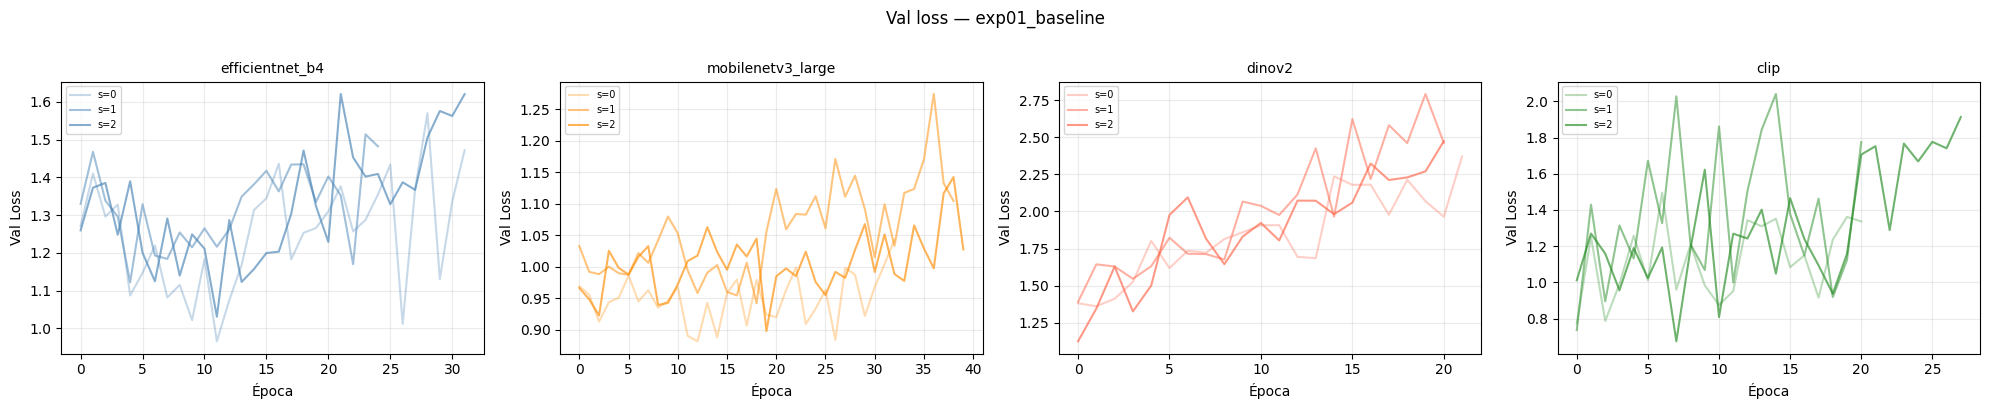

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/exp01_baseline/figuras/training_curves.png


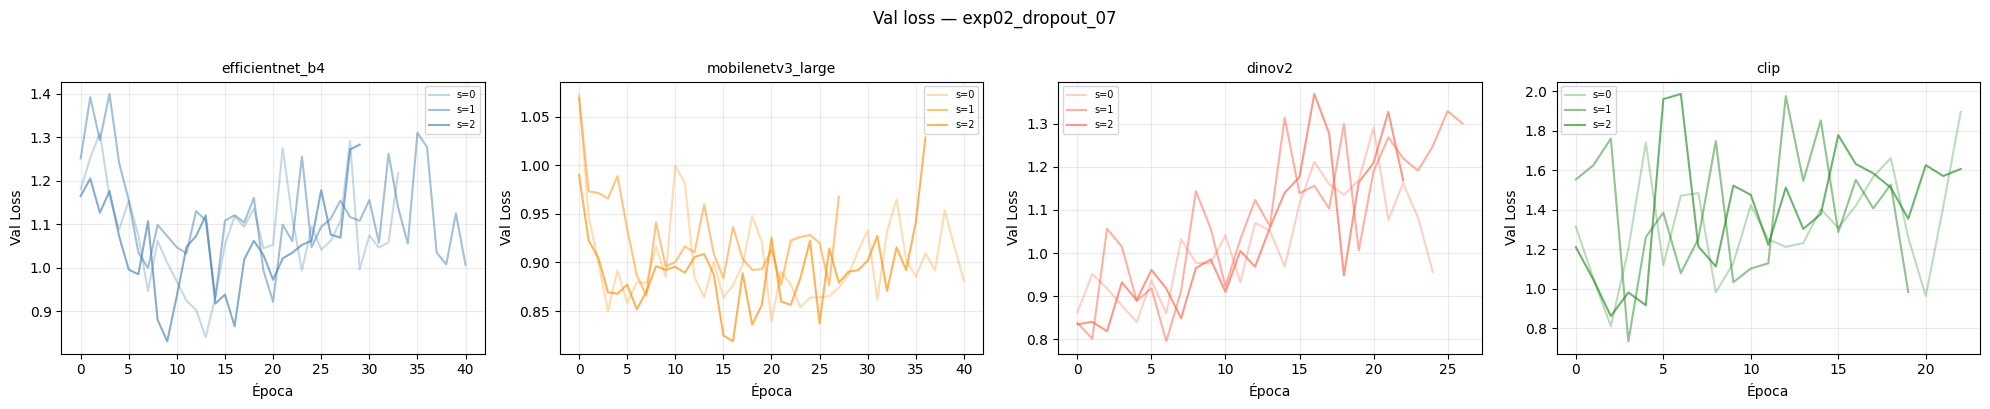

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/exp02_dropout_07/figuras/training_curves.png


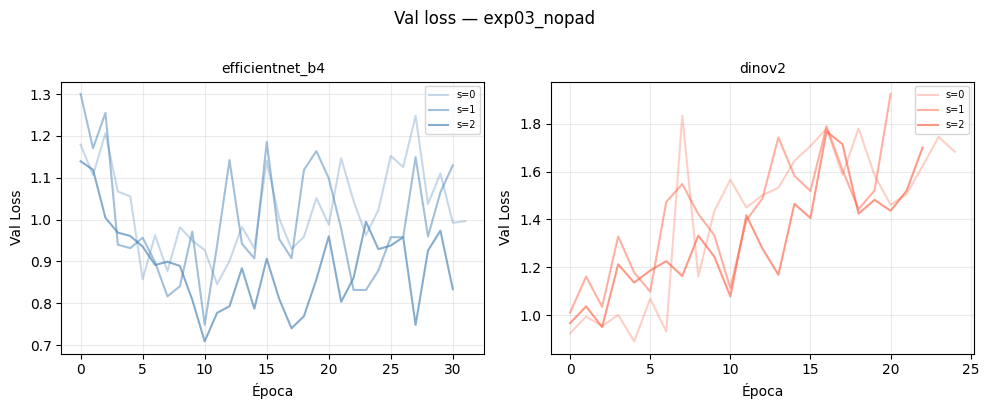

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/exp03_nopad/figuras/training_curves.png


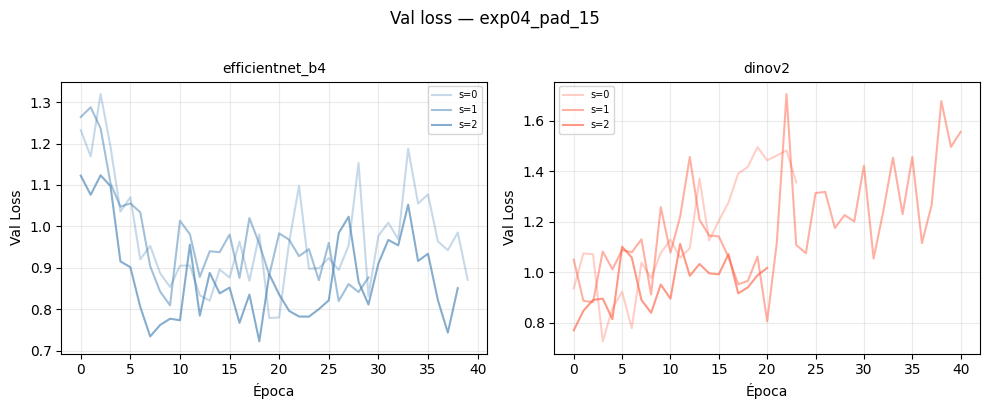

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/exp04_pad_15/figuras/training_curves.png
  Loaders (pad=8%, img=224px): train=13372 val=6805 test=6388


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

  EfficientNet-B4                 : 14,369,596 entrenables /   18,009,164 (79.8%)


model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

  MobileNetV3-Large               :    329,476 entrenables /    4,531,508 (7.3%)


...

  DINOv2 ViT-B/14 (unfreeze=0)    :    198,404 entrenables /   85,923,332 (0.2%)


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


  CLIP ViT-B/32                   : 14,308,612 entrenables /   87,982,084 (16.3%)
  EfficientNet-B4                 : 14,369,596 entrenables /   18,009,164 (79.8%)


  DINOv2 ViT-B/14 (unfreeze=0)    :    198,404 entrenables /   85,923,332 (0.2%)
  EfficientNet-B4                 : 14,369,596 entrenables /   18,009,164 (79.8%)


  DINOv2 ViT-B/14 (unfreeze=0)    :    198,404 entrenables /   85,923,332 (0.2%)


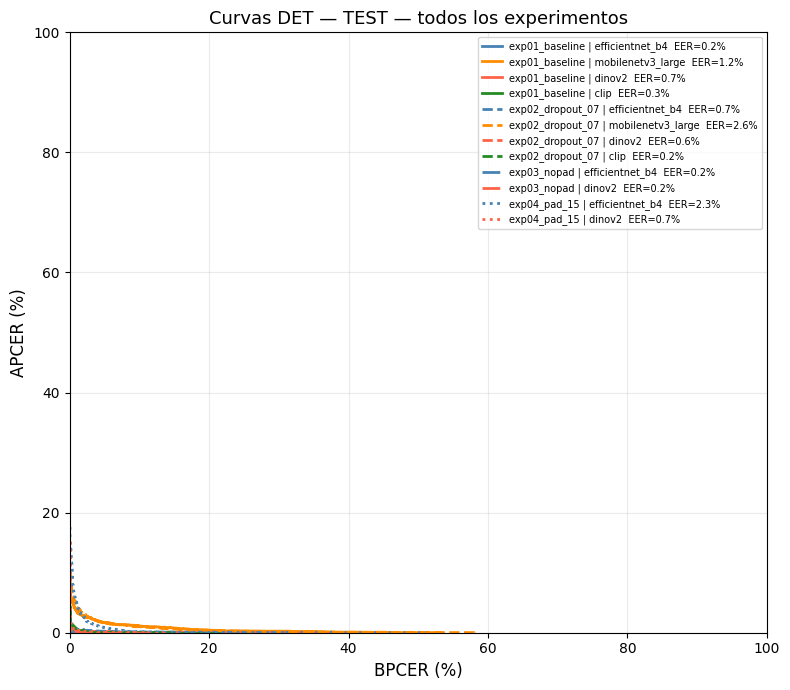

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/det_global_test.png
  Loaders (pad=8%, img=224px): train=13372 val=6805 test=6388
  EfficientNet-B4                 : 14,369,596 entrenables /   18,009,164 (79.8%)
  MobileNetV3-Large               :    329,476 entrenables /    4,531,508 (7.3%)


  DINOv2 ViT-B/14 (unfreeze=0)    :    198,404 entrenables /   85,923,332 (0.2%)


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


  CLIP ViT-B/32                   : 14,308,612 entrenables /   87,982,084 (16.3%)


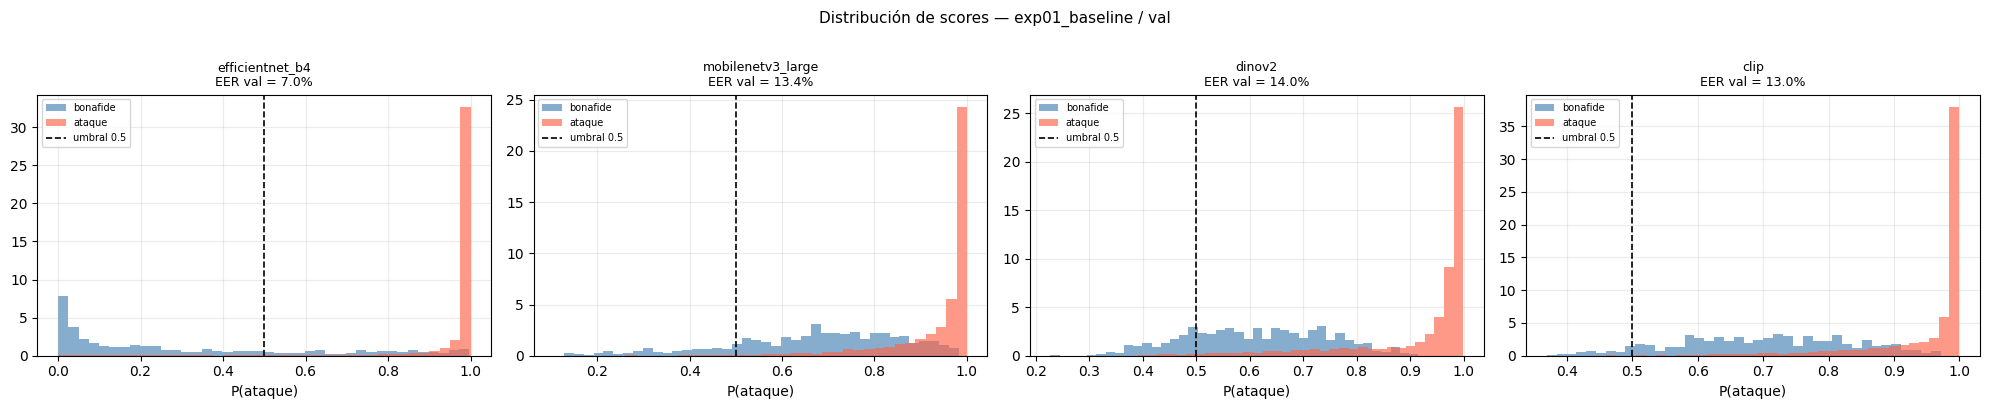

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/score_distributions.png


In [ ]:
MODEL_COLORS = {
    'efficientnet_b4':'steelblue','mobilenetv3_large':'darkorange',
    'dinov2':'tomato','clip':'forestgreen','vit_lora':'darkorchid'}
RUN_ALPHAS = [0.30,0.50,0.65,0.80,1.00]

def plot_training_curves_for_experiment(exp_config, ckpt_dir, fig_dir):
    models=exp_config['models_to_train']; seeds=exp_config['run_seeds']
    fig,axes=plt.subplots(1,len(models),figsize=(5*len(models),4))
    if len(models)==1: axes=[axes]
    for ax,mn in zip(axes,models):
        color=MODEL_COLORS.get(mn,'gray')
        for idx,seed in enumerate(seeds):
            ckpt=ckpt_dir/f'{mn}_run{seed}_resume.pt'
            if not ckpt.exists(): continue
            hist=torch.load(str(ckpt),map_location='cpu',weights_only=False)['history']
            ax.plot(hist['val_loss'],color=color,alpha=RUN_ALPHAS[idx%len(RUN_ALPHAS)],lw=1.5,label=f's={seed}')
        ax.set_title(mn,fontsize=10); ax.set_xlabel('Época'); ax.set_ylabel('Val Loss')
        ax.legend(fontsize=7); ax.grid(alpha=0.25)
    plt.suptitle(f'Val loss — {exp_config["exp_id"]}',fontsize=12,y=1.01)
    plt.tight_layout()
    path=str(fig_dir/'training_curves.png')
    fig.savefig(path,dpi=150,bbox_inches='tight'); plt.show(); print(f'Guardado: {path}')

def plot_det_comparison(experiments, all_results, loader, h2_base_dir, split='test'):
    fig,ax=plt.subplots(figsize=(8,7))
    linestyles=['-','--','-.',':',(0,(3,1,1,1))]
    for exp_idx,exp in enumerate(experiments):
        exp_id=exp['exp_id']; exp_res=all_results.get(exp_id,{})
        ckpt_dir=h2_base_dir/exp_id/'checkpoints'
        ls=linestyles[exp_idx%len(linestyles)]; config=build_config(BASE_CONFIG,exp)
        for mn in exp['models_to_train']:
            runs=exp_res.get(mn,[])
            if not runs: continue
            best_idx=int(np.argmin([r[split]['EER'] for r in runs]))
            best_seed=runs[best_idx]['run_seed']  # ← CORREGIDO
            ckpt_best=ckpt_dir/f'{mn}_run{best_seed}_best.pt'
            if not ckpt_best.exists(): continue
            model=get_model(mn,run_seed=best_seed,config=config)
            model.load_state_dict(torch.load(str(ckpt_best),map_location=DEVICE,weights_only=True))
            model.eval(); sc_list,lb_list=[],[]
            with torch.no_grad():
                for imgs,lm,_ in loader:
                    imgs=imgs.to(DEVICE)
                    with torch.amp.autocast('cuda'): logits=model(imgs)
                    probs=F.softmax(logits.float(),dim=1)
                    sc_list.extend((1.0-probs[:,0]).cpu().numpy())
                    lb_list.extend((lm!=0).long().numpy())
            sc=np.array(sc_list); lb=np.array(lb_list)
            eer=runs[best_idx][split]['EER']
            if len(np.unique(lb))>1:
                fpr_d,fnr_d,_=det_curve(lb,sc,pos_label=1)
                ax.plot(fpr_d*100,fnr_d*100,color=MODEL_COLORS.get(mn,'gray'),ls=ls,lw=2.0,
                        label=f'{exp_id} | {mn}  EER={eer*100:.1f}%')
            del model; gc.collect(); torch.cuda.empty_cache()
    ax.set_xlabel('BPCER (%)',fontsize=12); ax.set_ylabel('APCER (%)',fontsize=12)
    ax.set_title(f'Curvas DET — {split.upper()} — todos los experimentos',fontsize=13)
    ax.legend(fontsize=7,loc='upper right'); ax.grid(alpha=0.25)
    ax.set_xlim(0,100); ax.set_ylim(0,100); plt.tight_layout()
    path=str(h2_base_dir/f'det_global_{split}.png')
    fig.savefig(path,dpi=150,bbox_inches='tight'); plt.show(); print(f'Guardado: {path}')

def plot_score_distributions(experiments, all_results, train_df, val_df, test_df, h2_base_dir):
    exp=next((e for e in experiments if e['exp_id']=='exp01_baseline'),experiments[0])
    exp_res=all_results.get(exp['exp_id'],{})
    if not exp_res: print('Sin resultados para distribución de scores.'); return
    config=build_config(BASE_CONFIG,exp)
    _,loader_val,_,_=build_dataloaders(train_df,val_df,test_df,config)
    models_ok=[mn for mn in exp['models_to_train'] if exp_res.get(mn)]
    if not models_ok: return
    fig,axes=plt.subplots(1,len(models_ok),figsize=(5*len(models_ok),4))
    if len(models_ok)==1: axes=[axes]
    for ax,mn in zip(axes,models_ok):
        runs=exp_res.get(mn,[])
        best_idx=int(np.argmin([r['val']['EER'] for r in runs]))
        best_seed=runs[best_idx]['run_seed']  # ← CORREGIDO
        ckpt_best=h2_base_dir/exp['exp_id']/'checkpoints'/f'{mn}_run{best_seed}_best.pt'
        if not ckpt_best.exists(): ax.set_title(f'{mn}\n(checkpoint no encontrado)'); continue
        model=get_model(mn,run_seed=best_seed,config=config)
        model.load_state_dict(torch.load(str(ckpt_best),map_location=DEVICE,weights_only=True))
        model.eval(); scores,labels=[],[]
        with torch.no_grad():
            for imgs,lm,_ in loader_val:
                imgs=imgs.to(DEVICE)
                with torch.amp.autocast('cuda'): logits=model(imgs)
                probs=F.softmax(logits.float(),dim=1)
                scores.extend((1.0-probs[:,0]).cpu().numpy())
                labels.extend((lm!=0).long().numpy())
        del model; gc.collect(); torch.cuda.empty_cache()
        sc,lb=np.array(scores),np.array(labels)
        ax.hist(sc[lb==0],bins=40,alpha=0.65,label='bonafide',color='steelblue',density=True)
        ax.hist(sc[lb==1],bins=40,alpha=0.65,label='ataque',  color='tomato',   density=True)
        ax.axvline(0.5,ls='--',color='k',lw=1.2,label='umbral 0.5')
        ax.set_title(f'{mn}\nEER val = {runs[best_idx]["val"]["EER"]*100:.1f}%',fontsize=9)
        ax.set_xlabel('P(ataque)'); ax.legend(fontsize=7); ax.grid(alpha=0.25)
    plt.suptitle(f'Distribución de scores — exp01_baseline / val',fontsize=11,y=1.01)
    plt.tight_layout()
    path=str(h2_base_dir/'score_distributions.png')
    fig.savefig(path,dpi=150,bbox_inches='tight'); plt.show(); print(f'Guardado: {path}')

# Generar todas las visualizaciones
for exp in EXPERIMENTS_TO_RUN:
    dirs=get_experiment_dirs(exp['exp_id'])
    if _count_files(dirs['checkpoints'])>0:
        plot_training_curves_for_experiment(exp,dirs['checkpoints'],dirs['figuras'])

loader_test_global=None
for exp in EXPERIMENTS_TO_RUN:
    if ALL_RESULTS.get(exp['exp_id']):
        _,_,loader_test_global,_=build_dataloaders(TRAIN_DF,VAL_DF,TEST_DF,build_config(BASE_CONFIG,exp)); break
if loader_test_global:
    plot_det_comparison(EXPERIMENTS_TO_RUN,ALL_RESULTS,loader_test_global,H2_BASE_DIR)
    plot_score_distributions(EXPERIMENTS_TO_RUN,ALL_RESULTS,TRAIN_DF,VAL_DF,TEST_DF,H2_BASE_DIR)

## Crops para figuras de la memoria

Genera recortes horizontales de muestras representativas de cada tipo de ataque.
Cada imagen se rota a landscape si es necesario y se recorta la región central
para hacer zoom en la textura del documento. Los PNGs individuales y los collages
se guardan en hito2/crops_figuras/ para montarlos directamente en LaTeX.

In [ ]:
CROPS_DIR  = H2_BASE_DIR / 'crops_figuras'
CROPS_DIR.mkdir(parents=True, exist_ok=True)

N_MUESTRAS = 3      # imágenes por tipo de ataque
ZOOM_FRAC  = 0.80   # fracción central conservada (zoom sobre textura del documento)
RNG_CROPS  = np.random.default_rng(42)

TIPO_LABEL = {
    'bonafide':  'Bonafide',
    'print':     'Print attack',
    'screen':    'Screen capture',
    'composite': 'Composite',
}

In [ ]:
def _a_landscape(img):
    """Rota a horizontal si el crop está en portrait."""
    return img.rotate(90, expand=True) if img.height > img.width else img

def _recorte_central(img, frac):
    """Recorta la región central para hacer zoom en la textura."""
    w, h = img.size
    mw, mh = int(w*(1-frac)/2), int(h*(1-frac)/2)
    return img.crop((mw, mh, w-mw, h-mh))

def _hacer_collage(imgs_tipo, titulo, path_out, tw=320, th=200, gap=10):
    tipos  = [t for t in CLASS_NAMES if t in imgs_tipo]
    ancho  = N_MUESTRAS*tw + (N_MUESTRAS+1)*gap
    alto   = len(tipos)*th + (len(tipos)+1)*gap + 40
    lienzo = Image.new('RGB', (ancho, alto), (20, 20, 20))
    draw   = ImageDraw.Draw(lienzo)
    try:
        ft = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 16)
        fl = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', 13)
    except Exception:
        ft = fl = ImageFont.load_default()
    draw.text((gap, 10), titulo, fill=(255, 255, 255), font=ft)
    for r, tipo in enumerate(tipos):
        for c, img in enumerate(imgs_tipo[tipo][:N_MUESTRAS]):
            x = gap + c*(tw+gap)
            y = 40  + gap + r*(th+gap)
            lienzo.paste(img.resize((tw, th), Image.LANCZOS), (x, y))
            draw.rectangle([x, y, x+tw-1, y+th-1], outline=(55, 55, 55), width=1)
            if c == 0:
                draw.text((x+5, y+5), TIPO_LABEL.get(tipo, tipo), fill=(255, 210, 60), font=fl)
    lienzo.save(str(path_out), dpi=(300, 300))
    print(f'  collage  - {path_out.name}')

def _generar_latex(crops_guardados, ds_nombre, path_tex):
    """
    Genera un snippet .tex con subcaption listo para pegar en Overleaf.
    Requiere en el preámbulo: \\usepackage{subcaption}
    """
    tipos  = [t for t in CLASS_NAMES if t in crops_guardados]
    ancho  = f'{round(1.0/N_MUESTRAS - 0.02, 2):.2f}'
    ds_fmt = ds_nombre.replace('_', ' ')
    lines  = [
        r'% ──────────────────────────────────────────────────────────────────',
        f'% Crops de ataques — {ds_fmt}  (generado automáticamente)',
        r'% Requiere \usepackage{subcaption} en el preámbulo',
        r'% ──────────────────────────────────────────────────────────────────',
        r'\begin{figure}[ht]',
        r'  \centering',
    ]
    for tipo in tipos:
        fnames = crops_guardados[tipo]
        for i, fname in enumerate(fnames):
            lines.append(f'  \\begin{{subfigure}}[b]{{{ancho}\\linewidth}}')
            lines.append(f'    \\includegraphics[width=\\linewidth]{{figuras/crops/{fname}}}')
            lines.append(r'  \end{subfigure}\hfill')
        lines.append(r'  \\[4pt]')  # separación entre filas de tipo
    lines += [
        f'  \\caption{{Ejemplos representativos de cada categoría de ataque en {ds_fmt}.'
        f' De arriba abajo: \\textit{{bonafide}}, \\textit{{print attack}},'
        f' \\textit{{screen capture}} y \\textit{{composite}}.'
        f' Recorte SAM rotado a horizontal con zoom sobre la región del documento.}}',
        f'  \\label{{fig:crops_{ds_nombre.lower()}}}',
        r'\end{figure}',
        '',
    ]
    path_tex.write_text('\n'.join(lines), encoding='utf-8')
    print(f'  LaTeX    - {path_tex.name}')

# generación
for ds_nombre, df in [('ID_Cards', VAL_DF), ('SYN_PASS', TEST_DF)]:
    print(f'\n── {ds_nombre} ──')
    imgs_por_tipo   = {}
    crops_guardados = {}

    for tipo in CLASS_NAMES:
        variantes = ['print', 'printed'] if tipo == 'print' else [tipo]
        sub = df[df['tipo'].isin(variantes)]
        if sub.empty:
            print(f'  {tipo}: sin muestras'); continue

        idx   = RNG_CROPS.choice(len(sub), size=min(N_MUESTRAS, len(sub)), replace=False)
        imgs, fnames = [], []
        for _, fila in sub.iloc[idx].iterrows():
            try:
                img   = Image.open(fila['ruta']).convert('RGB')
                img   = _recorte_central(_a_landscape(img), ZOOM_FRAC)
                fname = f'{ds_nombre}_{tipo}_{len(imgs):02d}.png'
                img.save(str(CROPS_DIR / fname), dpi=(300, 300))
                imgs.append(img); fnames.append(fname)
            except Exception as e:
                print(f'  skip {Path(fila["ruta"]).name}: {e}')
        if imgs:
            imgs_por_tipo[tipo]   = imgs
            crops_guardados[tipo] = fnames
            print(f'  {tipo}: {len(imgs)} crops')

    if imgs_por_tipo:
        _hacer_collage(imgs_por_tipo,
                       f'{ds_nombre.replace("_", " ")} — ejemplos por tipo de ataque',
                       CROPS_DIR / f'collage_{ds_nombre}.png')
        _generar_latex(crops_guardados, ds_nombre,
                       CROPS_DIR / f'figura_{ds_nombre}.tex')

print(f'\nCrops en: {CROPS_DIR}')


── ID_Cards ──
  bonafide: 3 crops
  print: 3 crops
  screen: 3 crops
  composite: 3 crops
  collage  - collage_ID_Cards.png
  LaTeX    - figura_ID_Cards.tex

── SYN_PASS ──
  bonafide: 3 crops
  print: 3 crops
  screen: 3 crops
  composite: sin muestras
  collage  - collage_SYN_PASS.png
  LaTeX    - figura_SYN_PASS.tex

Crops en: /content/drive/MyDrive/TFM_ID_Cards/hito2/crops_figuras


  Loaders (pad=8%, img=224px): train=13372 val=6805 test=6388
  EfficientNet-B4                 : 14,369,596 entrenables /   18,009,164 (79.8%)


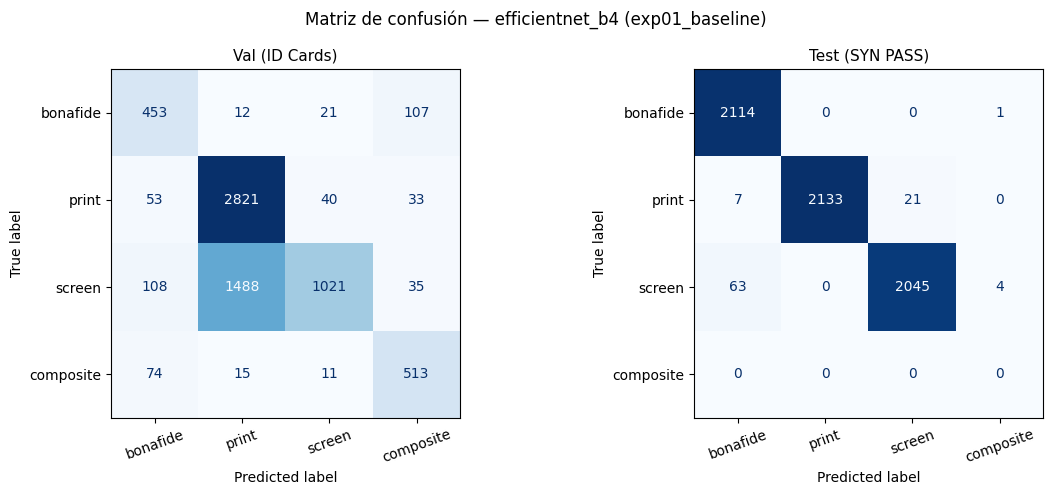

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/confusion_matrices/confmat_efficientnet_b4.png
  MobileNetV3-Large               :    329,476 entrenables /    4,531,508 (7.3%)


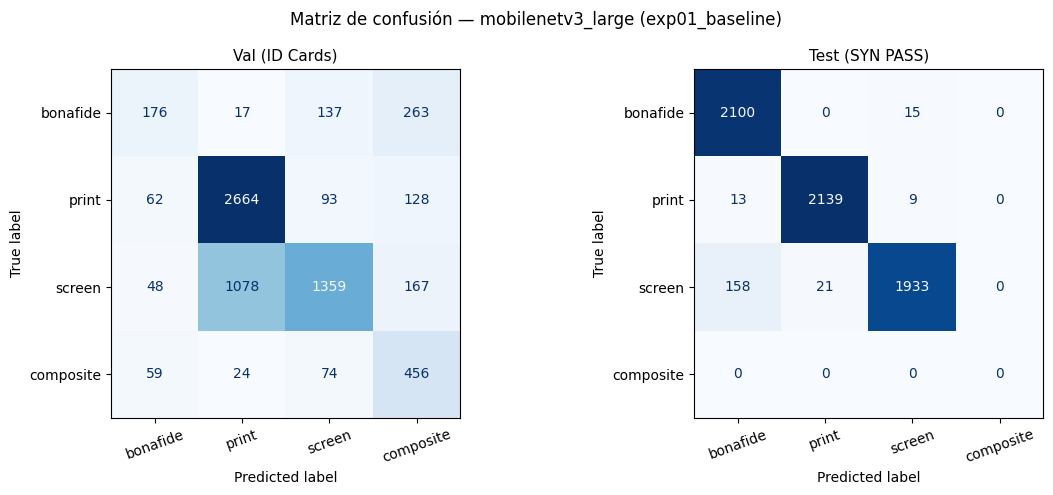

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/confusion_matrices/confmat_mobilenetv3_large.png


  DINOv2 ViT-B/14 (unfreeze=0)    :    198,404 entrenables /   85,923,332 (0.2%)


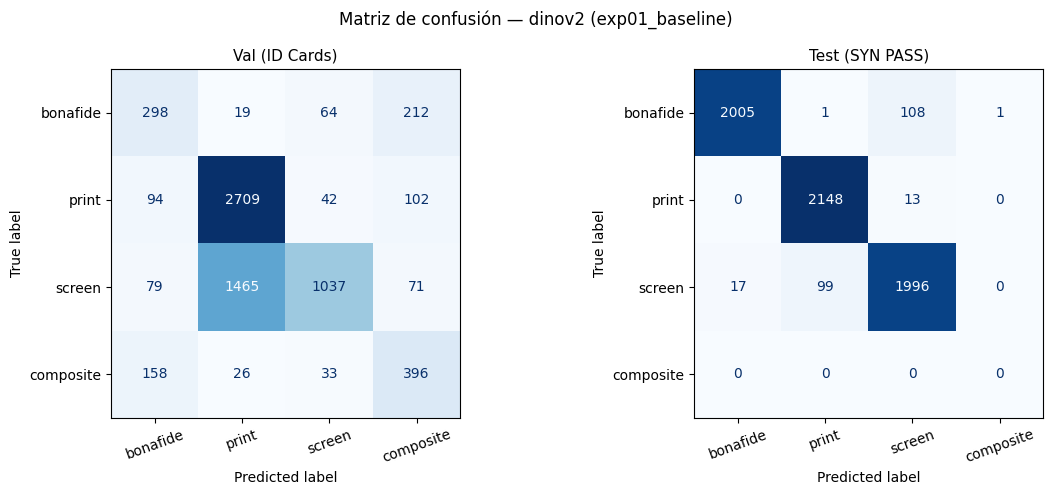

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/confusion_matrices/confmat_dinov2.png


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


  CLIP ViT-B/32                   : 14,308,612 entrenables /   87,982,084 (16.3%)


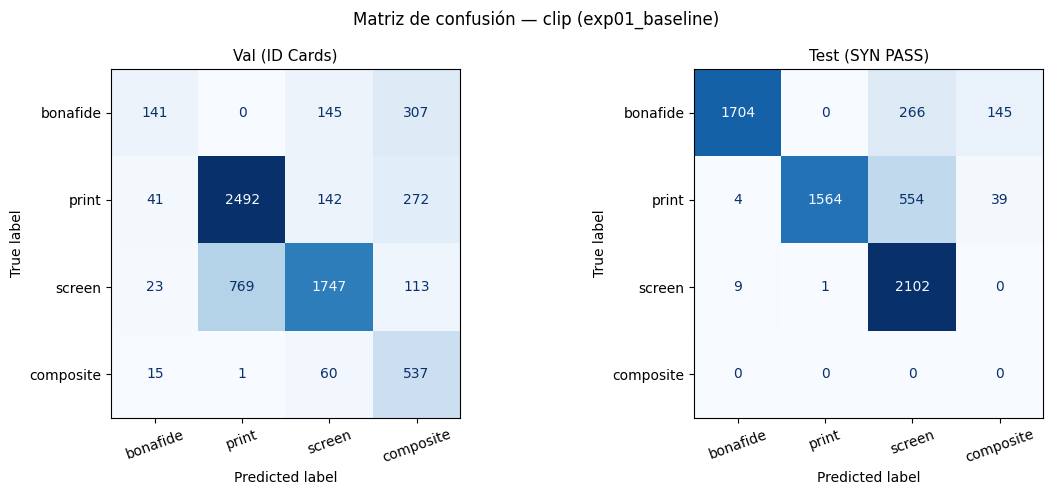

Guardado: /content/drive/MyDrive/TFM_ID_Cards/hito2/confusion_matrices/confmat_clip.png


In [ ]:

CONF_DIR = H2_BASE_DIR / 'confusion_matrices'
CONF_DIR.mkdir(exist_ok=True)

exp_base = next(e for e in EXPERIMENTS_TO_RUN if e['exp_id'] == 'exp01_baseline')
config   = build_config(BASE_CONFIG, exp_base)
_, loader_val_cm, loader_test_cm, _ = build_dataloaders(TRAIN_DF, VAL_DF, TEST_DF, config)

for mn in exp_base['models_to_train']:
    runs     = ALL_RESULTS['exp01_baseline'].get(mn, [])
    if not runs: continue
    best_idx = int(np.argmin([r['val']['EER'] for r in runs]))
    best_seed = runs[best_idx]['run_seed']
    ckpt_best = H2_BASE_DIR / 'exp01_baseline' / 'checkpoints' / f'{mn}_run{best_seed}_best.pt'
    if not ckpt_best.exists(): continue

    model = get_model(mn, run_seed=best_seed, config=config)
    model.load_state_dict(torch.load(str(ckpt_best), map_location=DEVICE, weights_only=True))
    model.eval()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (loader, titulo) in zip(axes, [(loader_val_cm,'Val (ID Cards)'),
                                            (loader_test_cm,'Test (SYN PASS)')]):
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, lm, _ in loader:
                logits = model(imgs.to(DEVICE))
                preds  = logits.argmax(dim=1).cpu().numpy()
                all_preds.extend(preds); all_labels.extend(lm.numpy())
        cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(CLASS_NAMES))))
        disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f'{titulo}', fontsize=11)
        ax.tick_params(axis='x', rotation=20)
    plt.suptitle(f'Matriz de confusión — {mn} (exp01_baseline)', fontsize=12)
    plt.tight_layout()
    path = str(CONF_DIR / f'confmat_{mn}.png')
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {path}')
    del model; gc.collect(); torch.cuda.empty_cache()

In [ ]:
backup = H2_BASE_DIR / f'ALL_RESULTS_backup_{datetime.date.today()}.json'
with open(backup, 'w') as f:
    json.dump(ALL_RESULTS, f, indent=2)
print(f'Backup  {backup}')

Backup  /content/drive/MyDrive/TFM_ID_Cards/hito2/ALL_RESULTS_backup_2026-06-08.json
